# Time Series Classification (ECG200 Dataset) 🩺📈

Welcome to the comprehensive guide on **Time Series Classification (TSC)**. Unlike time series forecasting (which predicts future values of a sequence), Time Series Classification aims to assign a discrete label or class to an entire time series sequence.

### Real-World Use Cases
- **Healthcare:** Classifying ECG/EEG signals to detect anomalies or diseases (e.g., myocardial infarction, epilepsy).
- **Human Activity Recognition (HAR):** Classifying accelerometer/gyroscope signals from wearables into actions (walking, running, sleeping).
- **Industrial IoT:** Detecting equipment failures or defects from vibration sensor signals.
- **Finance:** Classifying stock price movements or trade patterns.

---

## 📖 Core Concepts in Time Series Classification

There are three main paradigms for solving TSC problems:
1. **Feature-based Classification:** Transform the time series into static features (e.g., mean, variance, autocorrelation, Fourier coefficients) and use standard ML classifiers (Random Forests, Gradient Boosting).
2. **Distance-based Classification:** Compute similarity directly between raw sequences using temporal distance measures like **Dynamic Time Warping (DTW)** and classify using a Nearest Neighbor (KNN) approach.
3. **Deep Learning (End-to-End):** Train deep networks (such as 1D Convolutional Neural Networks or LSTMs) directly on the raw sequences to automatically learn discriminative spatial-temporal features.

---

## 📊 About the ECG200 Dataset
- **Source:** Originally formatted by R. Olszewski for his 2001 thesis, derived from the UCR Time Series Archive.
- **Task:** Binary classification of electrical activity during a heartbeat.
- **Classes:** 
  - `1`: Normal heartbeat
  - `-1`: Myocardial Infarction (heart attack / abnormal heartbeat)
- **Data Shape:** 100 Training samples, 100 Testing samples. Each sequence consists of **96 time steps**.

Let's get started!

## 🛠️ 1. Setup & Imports

In [1]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.0.1
CUDA available: False


## 📥 2. Load and Inspect the Dataset

The dataset is stored in `data/ECG200_TRAIN.tsv` and `data/ECG200_TEST.tsv`.

In [2]:
# File paths
train_path = 'data/ECG200_TRAIN.tsv'
test_path = 'data/ECG200_TEST.tsv'

# Check if files exist, if not download them
if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("Downloading dataset...")
    os.makedirs('data', exist_ok=True)
    urllib.request.urlretrieve('https://raw.githubusercontent.com/Shuchismita-Biswas/AML_Project_Fall19/master/ECG200_TRAIN.tsv', train_path)
    urllib.request.urlretrieve('https://raw.githubusercontent.com/Shuchismita-Biswas/AML_Project_Fall19/master/ECG200_TEST.tsv', test_path)
    print("Download completed.")
else:
    print("Dataset files found locally.")

# Load datasets (tab-separated, no headers)
train_df = pd.read_csv(train_path, sep='\s+', header=None)
test_df = pd.read_csv(test_path, sep='\s+', header=None)

# Extract labels and signals
# First column is the class label (-1.0 or 1.0)
y_train = train_df.iloc[:, 0].values.astype(int)
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values.astype(int)
X_test = test_df.iloc[:, 1:].values

print(f"Train set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

Dataset files found locally.
Train set shape: X=(100, 96), y=(100,)
Test set shape: X=(100, 96), y=(100,)


### Visualize Heartbeat Signals

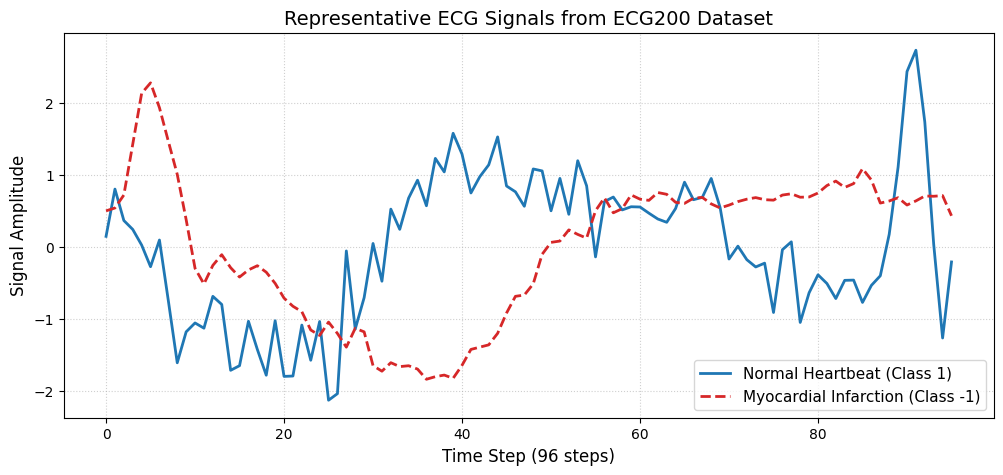

In [3]:
# Plot representative signals of both classes
normal_idx = np.where(y_train == 1)[0][0]
abnormal_idx = np.where(y_train == -1)[0][0]

plt.figure(figsize=(12, 5))
plt.plot(X_train[normal_idx], label='Normal Heartbeat (Class 1)', color='#1f77b4', lw=2)
plt.plot(X_train[abnormal_idx], label='Myocardial Infarction (Class -1)', color='#d62728', lw=2, linestyle='--')
plt.title('Representative ECG Signals from ECG200 Dataset', fontsize=14)
plt.xlabel('Time Step (96 steps)', fontsize=12)
plt.ylabel('Signal Amplitude', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## 🌲 3. Approach 1: Feature-based Machine Learning

In this approach, we map the 96-dimensional signal into simple statistical and frequency-domain features, and then train a Random Forest Classifier.

In [4]:
def extract_features(X):
    features = []
    for row in X:
        # 1. Statistical features
        mean_val = np.mean(row)
        std_val = np.std(row)
        max_val = np.max(row)
        min_val = np.min(row)
        peak_to_peak = max_val - min_val
        skew_val = pd.Series(row).skew() # Skewness
        kurt_val = pd.Series(row).kurt() # Kurtosis
        
        # 2. Time-series dynamics
        slope = np.polyfit(np.arange(len(row)), row, 1)[0] # Linear slope
        zero_crossings = np.sum(np.diff(np.sign(row)) != 0)
        
        # 3. Frequency domain (Fast Fourier Transform)
        fft_vals = np.abs(np.fft.rfft(row))
        fft_mean = np.mean(fft_vals)
        fft_std = np.std(fft_vals)
        fft_max = np.max(fft_vals)
        
        feature_vec = [
            mean_val, std_val, max_val, min_val, peak_to_peak, 
            skew_val, kurt_val, slope, zero_crossings,
            fft_mean, fft_std, fft_max
        ]
        features.append(feature_vec)
        
    return np.array(features)

# Extract features
X_train_feats = extract_features(X_train)
X_test_feats = extract_features(X_test)

# Handle any NaNs/Infs that skewness or kurtosis might return for edge cases
X_train_feats = np.nan_to_num(X_train_feats)
X_test_feats = np.nan_to_num(X_test_feats)

print(f"Extracted feature shape: Train={X_train_feats.shape}, Test={X_test_feats.shape}")

Extracted feature shape: Train=(100, 12), Test=(100, 12)


### Train Random Forest Classifier

In [5]:
# Scale features
scaler = StandardScaler()
X_train_feats_scaled = scaler.fit_transform(X_train_feats)
X_test_feats_scaled = scaler.transform(X_test_feats)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feats_scaled, y_train)

# Predict on test set
rf_preds = rf_model.predict(X_test_feats_scaled)
rf_probs = rf_model.predict_proba(X_test_feats_scaled)[:, 1]

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.7600


### Feature Importance Analysis

/var/folders/xf/gcbfh98s6n53wh5f2hpb84nh0000gn/T/ipykernel_89612/1353503996.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


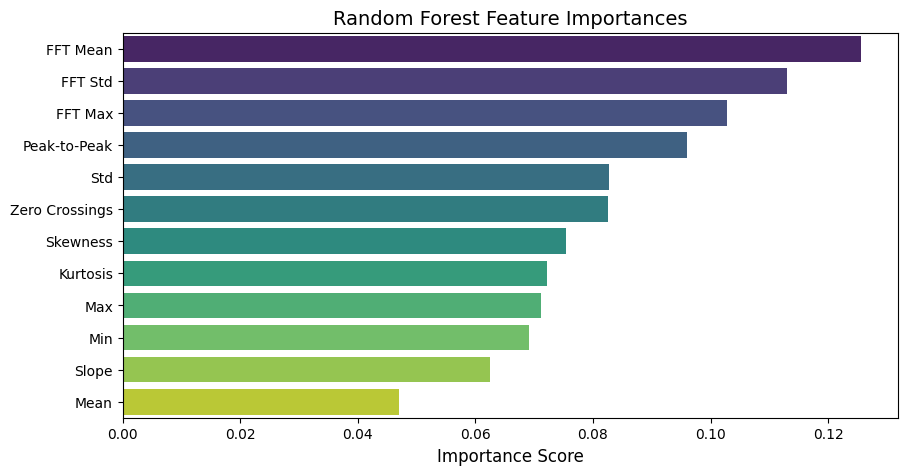

In [6]:
feature_names = [
    'Mean', 'Std', 'Max', 'Min', 'Peak-to-Peak', 
    'Skewness', 'Kurtosis', 'Slope', 'Zero Crossings',
    'FFT Mean', 'FFT Std', 'FFT Max'
]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Random Forest Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.show()

## 🕸️ 4. Approach 2: Deep Learning (1D CNN in PyTorch)

Convolutional Neural Networks are highly effective for univariate time series classification because 1D filters can capture local patterns (like the QRS complex or T-wave in heartbeats) regardless of their specific timing location.

In [7]:
# Preprocess labels: Class labels in ECG200 are -1 and 1. We must map them to 0 and 1 for cross-entropy loss
y_train_mapped = np.where(y_train == -1, 0, 1)
y_test_mapped = np.where(y_test == -1, 0, 1)

# Convert to PyTorch tensors
# CNN expects input shape (batch_size, channels, sequence_length). Channels = 1 for univariate.
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train_mapped, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test_mapped, dtype=torch.long)

print("Tensor shapes:")
print(f"X_train_t: {X_train_t.shape}, y_train_t: {y_train_t.shape}")
print(f"X_test_t: {X_test_t.shape}, y_test_t: {y_test_t.shape}")

# Build Dataloaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Tensor shapes:
X_train_t: torch.Size([100, 1, 96]), y_train_t: torch.Size([100])
X_test_t: torch.Size([100, 1, 96]), y_test_t: torch.Size([100])


### Define 1D CNN Architecture

In [8]:
class TimeSeriesCNN1D(nn.Module):
    def __init__(self):
        super(TimeSeriesCNN1D, self).__init__()
        
        # Conv Block 1
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # 96 -> 48
        
        # Conv Block 2
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2) # 48 -> 24
        
        # Conv Block 3
        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2) # 24 -> 12
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 12, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 2)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = TimeSeriesCNN1D()
print(model)

TimeSeriesCNN1D(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=768, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


### Training Loop

In [9]:
# Select Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Train Model
epochs = 40
train_losses = []
test_accs = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * inputs.size(0)
    
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Evaluate accuracy on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    test_acc = correct / total
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch [5/40] | Train Loss: 0.2135 | Test Acc: 0.8500
Epoch [10/40] | Train Loss: 0.1102 | Test Acc: 0.8400
Epoch [15/40] | Train Loss: 0.0194 | Test Acc: 0.8800
Epoch [20/40] | Train Loss: 0.0066 | Test Acc: 0.8900
Epoch [25/40] | Train Loss: 0.0027 | Test Acc: 0.8700
Epoch [30/40] | Train Loss: 0.0027 | Test Acc: 0.8900
Epoch [35/40] | Train Loss: 0.0025 | Test Acc: 0.8800
Epoch [40/40] | Train Loss: 0.0009 | Test Acc: 0.8800


### Plot Training Dynamics

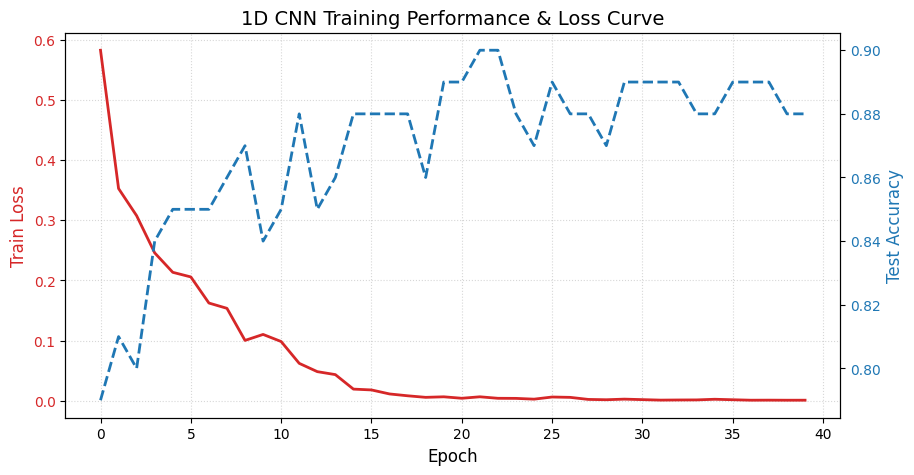

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#d62728'
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Train Loss', color=color, fontsize=12)
ax1.plot(train_losses, color=color, label='Train Loss', lw=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
color = '#1f77b4'
ax2.set_ylabel('Test Accuracy', color=color, fontsize=12)
ax2.plot(test_accs, color=color, label='Test Accuracy', lw=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('1D CNN Training Performance & Loss Curve', fontsize=14)
plt.show()

## 📈 5. Model Evaluation and Comparison

Let's compare the performance of our Random Forest Classifier and PyTorch 1D CNN Classifier on the test set.

In [11]:
# CNN Predictions
model.eval()
cnn_preds = []
cnn_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)
        
        cnn_preds.extend(predicted.cpu().numpy())
        cnn_probs.extend(probs.cpu().numpy())

cnn_preds = np.array(cnn_preds)
cnn_probs = np.array(cnn_probs)

# Convert y_test_mapped (0 and 1) back to class labels -1 and 1 for standard formatting
# cnn preds: 0 -> -1, 1 -> 1
cnn_preds_labels = np.where(cnn_preds == 0, -1, 1)

# Evaluate CNN
cnn_acc = accuracy_score(y_test, cnn_preds_labels)
print("Random Forest Classifier Accuracy:", rf_acc)
print("1D Convolutional Neural Network Accuracy:", cnn_acc)

Random Forest Classifier Accuracy: 0.76
1D Convolutional Neural Network Accuracy: 0.88


### Classification Reports & Confusion Matrices

In [12]:
print("=== RANDOM FOREST CLASSIFICATION REPORT ===")
print(classification_report(y_test, rf_preds, target_names=['Abnormal (-1)', 'Normal (1)']))

print("=== 1D CNN CLASSIFICATION REPORT ===")
print(classification_report(y_test, cnn_preds_labels, target_names=['Abnormal (-1)', 'Normal (1)']))

=== RANDOM FOREST CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Abnormal (-1)       0.73      0.53      0.61        36
   Normal (1)       0.77      0.89      0.83        64

     accuracy                           0.76       100
    macro avg       0.75      0.71      0.72       100
 weighted avg       0.76      0.76      0.75       100

=== 1D CNN CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Abnormal (-1)       0.85      0.81      0.83        36
   Normal (1)       0.89      0.92      0.91        64

     accuracy                           0.88       100
    macro avg       0.87      0.86      0.87       100
 weighted avg       0.88      0.88      0.88       100



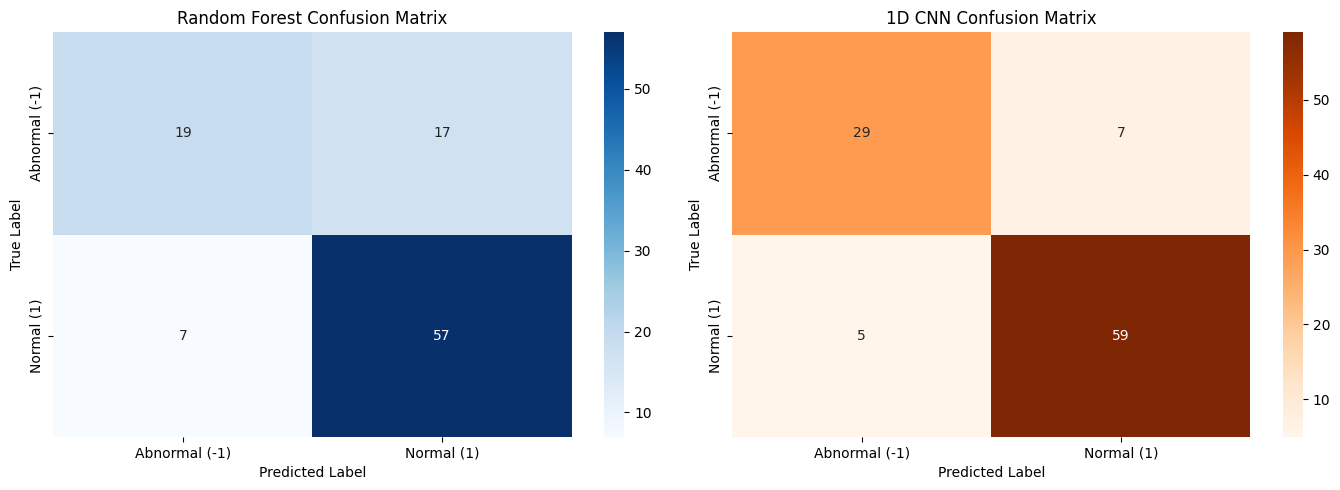

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest CM
rf_cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Abnormal (-1)', 'Normal (1)'], 
            yticklabels=['Abnormal (-1)', 'Normal (1)'])
axes[0].set_title('Random Forest Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# CNN CM
cnn_cm = confusion_matrix(y_test, cnn_preds_labels)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Abnormal (-1)', 'Normal (1)'], 
            yticklabels=['Abnormal (-1)', 'Normal (1)'])
axes[1].set_title('1D CNN Confusion Matrix', fontsize=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### ROC Curves

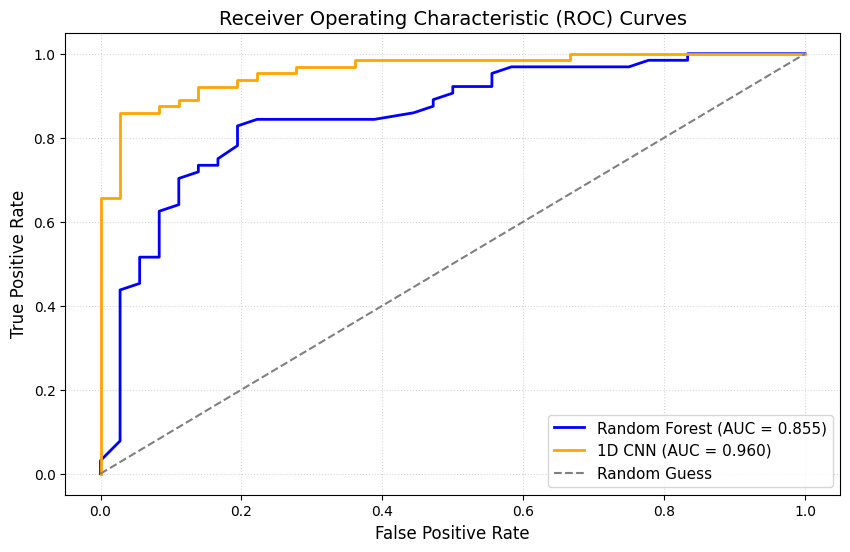

In [14]:
# RF ROC metrics
rf_auc = roc_auc_score(y_test, rf_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# CNN ROC metrics
cnn_auc = roc_auc_score(y_test_mapped, cnn_probs)
cnn_fpr, cnn_tpr, _ = roc_curve(y_test_mapped, cnn_probs)

plt.figure(figsize=(10, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='blue', lw=2)
plt.plot(cnn_fpr, cnn_tpr, label=f'1D CNN (AUC = {cnn_auc:.3f})', color='orange', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

## 💡 6. Summary and Key Takeaways

- **Feature-based Approach:** Fast, easily interpretable (via feature importance), and simple to implement. However, it relies heavily on manual feature engineering. If key features are missed, model performance degrades.
- **End-to-End Deep Learning:** Highly effective and automated (no manual feature engineering needed). 1D CNNs extract spatial-temporal filters directly from raw signals and can handle shifts or local anomalies extremely well. For complex time series patterns, deep learning is often the state-of-the-art solution.